# Notebook 2 – Treinamento de Detectores de Drift

## Aula 5: Drift em Embeddings e Testes de Duas Amostras

### Objetivos
- Implementar o cálculo de **MMD (Maximum Mean Discrepancy)** com kernel RBF (Gretton et al., 2012)
- Aplicar o **teste de Kolmogorov-Smirnov** para detecção de drift por dimensão (Massey, 1951)
- Treinar um **classificador adversário** como detector de drift (Lopez-Paz & Oquab, 2017)
- Calibrar limiares de detecção usando dados de referência

### Contexto Teórico (Documento da Aula 5)
> *"A MMD é um teste de duas amostras que calcula a distância entre as distribuições de dois conjuntos de dados no espaço de reproducing kernel."* (Gretton et al., 2012)

> *"MMD²(P_ref, P_novo) = E[k(x,x')] + E[k(y,y')] - 2E[k(x,y)]"*

**Vídeos relacionados:** Vídeo 3 (Extração de embeddings e MMD com BERT)

In [1]:
# Imports
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import ks_2samp

sys.path.insert(0, str(Path('..').resolve()))

from src.utils import set_seed, generate_synthetic_dataset
from src.data_preprocessing import DataPreprocessor
from src.model import EmbeddingDriftDetector
from src.training import (
    train_adversarial_classifier,
    compute_reference_statistics,
    hyperparameter_tuning,
)

plt.style.use('seaborn-v0_8-whitegrid')
set_seed(42)

print('Imports carregados com sucesso!')

Imports carregados com sucesso!


## 1. Carregamento e Preparação dos Dados

In [2]:
# Carrega dados
dataset_path = Path('..') / 'data' / 'raw' / 'dataset.csv'
if not dataset_path.exists():
    generate_synthetic_dataset(output_path=str(dataset_path))

preprocessor = DataPreprocessor(embedding_dim=64)
df = preprocessor.load_data(str(dataset_path))
df = preprocessor.clean_data()

# Separa referência vs produção
emb_ref, emb_prod_all, df_ref, df_prod_all = preprocessor.split_data()

# Separa produção em estável e com drift
emb_cols = preprocessor.embedding_cols
emb_stable = df_prod_all[df_prod_all['period'] == 'production_stable'][emb_cols].values
emb_drift = df_prod_all[df_prod_all['period'] == 'production_drift'][emb_cols].values

print(f'Referência: {emb_ref.shape}')
print(f'Produção estável: {emb_stable.shape}')
print(f'Produção com drift: {emb_drift.shape}')

Referência: (5000, 64)
Produção estável: (2500, 64)
Produção com drift: (2500, 64)


## 2. MMD (Maximum Mean Discrepancy)

Conforme a seção *'Saiba Mais'* do documento da Aula 5:

> *"A MMD mapeia as amostras para um espaço de características de dimensão possivelmente
> infinita por meio de uma função kernel k(.,.) e compara as médias das duas 
> distribuições nesse espaço."* (Gretton et al., 2012)

$$\mathrm{MMD}^2(P_{\text{ref}}, P_{\text{novo}}) = \mathbb{E}_{x,x'}[k(x,x')] + \mathbb{E}_{y,y'}[k(y,y')] - 2\mathbb{E}_{x,y}[k(x,y)]$$

Este código implementa o **Snippet 2** do Hands On do documento.

In [3]:
# Implementação direta do MMD conforme Snippet 2 da seção Hands On
# Implementa o cálculo de MMD^2 com kernel RBF (Gretton et al., 2012)

def compute_mmd_rbf(X, Y, gamma=0.5):
    """Calcula MMD² com kernel RBF gaussiano.
    
    Implementa a fórmula de Gretton et al. (2012) conforme
    apresentada na seção 'Saiba Mais' do documento da Aula 5.
    """
    KXX = rbf_kernel(X, X, gamma=gamma)
    KYY = rbf_kernel(Y, Y, gamma=gamma)
    KXY = rbf_kernel(X, Y, gamma=gamma)
    mmd2 = KXX.mean() + KYY.mean() - 2 * KXY.mean()
    return mmd2

# Testa com diferentes cenários
# Subsample para velocidade
n_test = 500
ref_sample = emb_ref[np.random.choice(len(emb_ref), n_test, replace=False)]
stable_sample = emb_stable[np.random.choice(len(emb_stable), n_test, replace=False)]
drift_sample = emb_drift[np.random.choice(len(emb_drift), n_test, replace=False)]

mmd_ref_stable = compute_mmd_rbf(ref_sample, stable_sample, gamma=0.1)
mmd_ref_drift = compute_mmd_rbf(ref_sample, drift_sample, gamma=0.1)
mmd_ref_ref = compute_mmd_rbf(ref_sample[:250], ref_sample[250:], gamma=0.1)

print('=== MMD² (Gretton et al., 2012) ===')
print(f'Ref vs Ref (baseline):        {mmd_ref_ref:.6f}')
print(f'Ref vs Produção Estável:      {mmd_ref_stable:.6f}')
print(f'Ref vs Produção com Drift:    {mmd_ref_drift:.6f}')
print()
print('Conforme documento: "Se as distribuições forem idênticas, a MMD tende a 0;')
print('caso contrário, assume valores positivos crescentes conforme o drift se acentua."')

=== MMD² (Gretton et al., 2012) ===
Ref vs Ref (baseline):        0.007851
Ref vs Produção Estável:      0.004011
Ref vs Produção com Drift:    0.011249

Conforme documento: "Se as distribuições forem idênticas, a MMD tende a 0;
caso contrário, assume valores positivos crescentes conforme o drift se acentua."


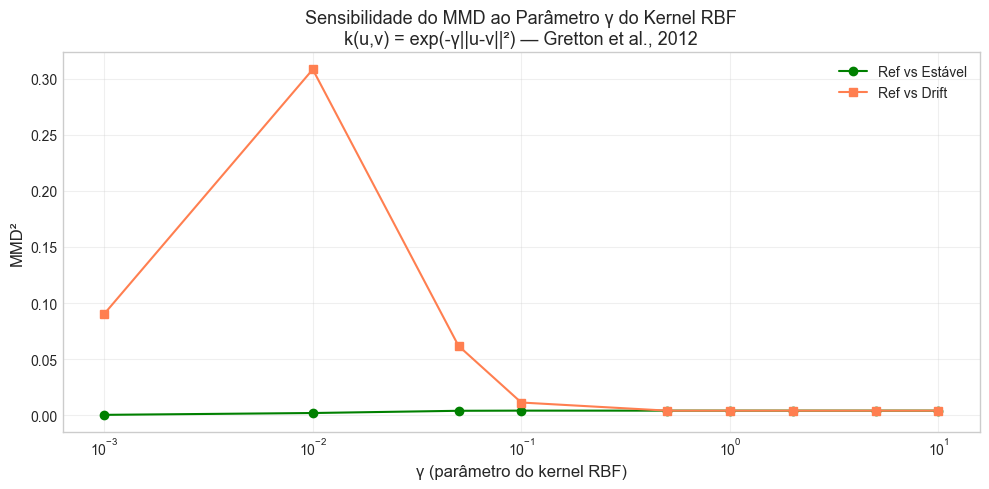

In [4]:
# Sensibilidade do MMD ao parâmetro gamma do kernel RBF
# Conforme Aula 5: gamma determina o grau de sensibilidade a diferenças locais

gammas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
mmd_stable_by_gamma = []
mmd_drift_by_gamma = []

for g in gammas:
    mmd_s = compute_mmd_rbf(ref_sample, stable_sample, gamma=g)
    mmd_d = compute_mmd_rbf(ref_sample, drift_sample, gamma=g)
    mmd_stable_by_gamma.append(mmd_s)
    mmd_drift_by_gamma.append(mmd_d)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gammas, mmd_stable_by_gamma, 'o-', label='Ref vs Estável', color='green')
ax.plot(gammas, mmd_drift_by_gamma, 's-', label='Ref vs Drift', color='coral')
ax.set_xscale('log')
ax.set_xlabel('γ (parâmetro do kernel RBF)', fontsize=12)
ax.set_ylabel('MMD²', fontsize=12)
ax.set_title('Sensibilidade do MMD ao Parâmetro γ do Kernel RBF\n'
             'k(u,v) = exp(-γ||u-v||²) — Gretton et al., 2012', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/mmd_gamma_sensibilidade.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Calibração do Limiar de MMD

Conforme o documento da Aula 5:
> *"A decisão estatística é tomada comparando-se o valor observado da MMD com uma
> distribuição crítica (derivada teoricamente ou via simulações/permutações)."*

Calculando distribuição baseline do MMD (bootstrap)...

Estatísticas de baseline (H0: sem drift):
  MMD² médio:       0.000796
  Desvio padrão:    0.000015
  Limiar 95%:       0.000820
  Limiar 99%:       0.000836


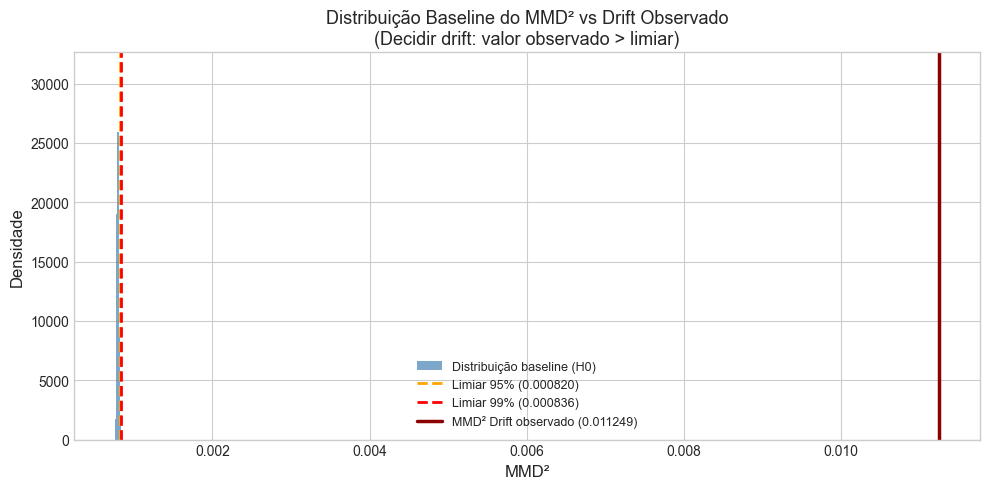

In [5]:
# Calcula distribuição de baseline do MMD via bootstrap dos dados de referência
print('Calculando distribuição baseline do MMD (bootstrap)...')
ref_stats = compute_reference_statistics(
    emb_ref, gamma=0.1, n_bootstrap=200, seed=42
)

print(f'\nEstatísticas de baseline (H0: sem drift):')
print(f'  MMD² médio:       {ref_stats["mean_mmd"]:.6f}')
print(f'  Desvio padrão:    {ref_stats["std_mmd"]:.6f}')
print(f'  Limiar 95%:       {ref_stats["threshold_95"]:.6f}')
print(f'  Limiar 99%:       {ref_stats["threshold_99"]:.6f}')

# Visualização da distribuição baseline
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ref_stats['mmd_scores'], bins=30, density=True, alpha=0.7,
        color='steelblue', label='Distribuição baseline (H0)')
ax.axvline(ref_stats['threshold_95'], color='orange', linestyle='--',
           linewidth=2, label=f'Limiar 95% ({ref_stats["threshold_95"]:.6f})')
ax.axvline(ref_stats['threshold_99'], color='red', linestyle='--',
           linewidth=2, label=f'Limiar 99% ({ref_stats["threshold_99"]:.6f})')
ax.axvline(mmd_ref_drift, color='darkred', linewidth=2.5,
           label=f'MMD² Drift observado ({mmd_ref_drift:.6f})')

ax.set_xlabel('MMD²', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.set_title('Distribuição Baseline do MMD² vs Drift Observado\n'
             '(Decidir drift: valor observado > limiar)', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/mmd_baseline_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Teste de Kolmogorov-Smirnov (KS)

Conforme a seção *'Saiba Mais'* da Aula 5 (Snippet 3 do Hands On):

> *"O teste KS calcula a distância máxima entre as funções de distribuição acumulada
> (FDA) empíricas das duas amostras."* (Massey, 1951)

$$D_{n,m} = \sup_x |F_{\text{ref}}(x) - F_{\text{novo}}(x)|$$

In [6]:
# Teste KS por dimensão conforme Snippet 3 do documento
detector_ks = EmbeddingDriftDetector(method='ks')

# KS nos dados estáveis (sem drift esperado)
ks_stable = detector_ks.compute_ks_test(ref_sample, stable_sample)
print('=== KS: Referência vs Produção Estável ===')
print(f'Max D-statistic:    {ks_stable["max_d"]:.4f}')
print(f'P-value ajustado:   {ks_stable["adjusted_p_value"]:.6f}')
print(f'Drift detectado:    {ks_stable["adjusted_p_value"] < 0.05}')

# KS nos dados com drift
ks_drift = detector_ks.compute_ks_test(ref_sample, drift_sample)
print(f'\n=== KS: Referência vs Produção com Drift ===')
print(f'Max D-statistic:    {ks_drift["max_d"]:.4f}')
print(f'P-value ajustado:   {ks_drift["adjusted_p_value"]:.6f}')
print(f'Drift detectado:    {ks_drift["adjusted_p_value"] < 0.05}')

=== KS: Referência vs Produção Estável ===
Max D-statistic:    0.1020
P-value ajustado:   0.702014
Drift detectado:    False

=== KS: Referência vs Produção com Drift ===
Max D-statistic:    0.5480
P-value ajustado:   0.000000
Drift detectado:    True


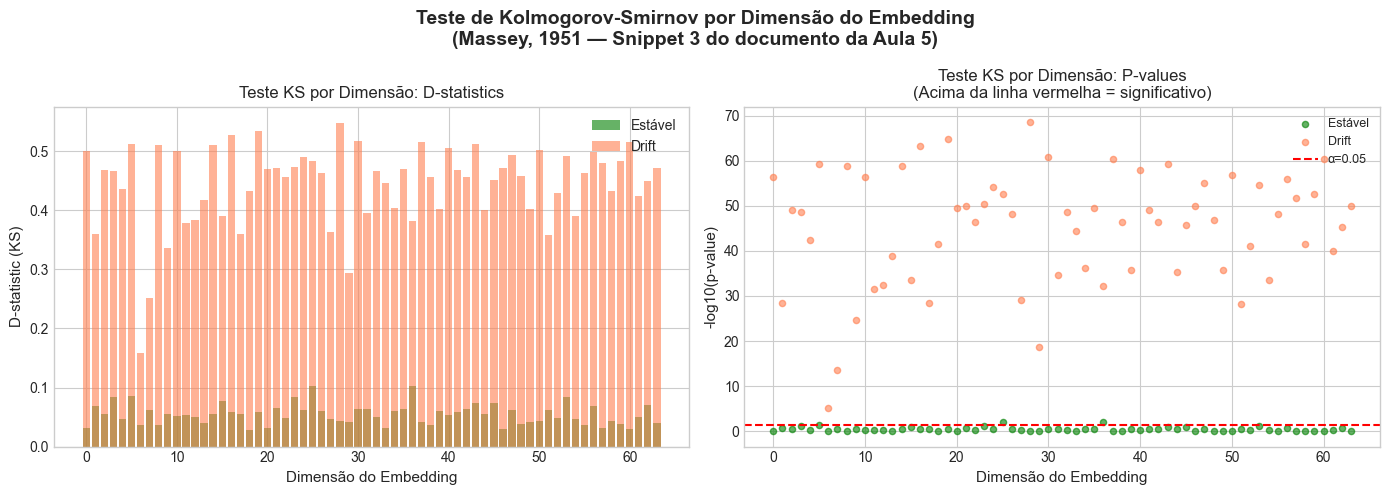

In [7]:
# Visualização do KS por dimensão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# D-statistics por dimensão
ax = axes[0]
ax.bar(range(64), ks_stable['d_statistics'], alpha=0.6, label='Estável', color='green')
ax.bar(range(64), ks_drift['d_statistics'], alpha=0.6, label='Drift', color='coral')
ax.set_xlabel('Dimensão do Embedding', fontsize=11)
ax.set_ylabel('D-statistic (KS)', fontsize=11)
ax.set_title('Teste KS por Dimensão: D-statistics', fontsize=12)
ax.legend(fontsize=10)

# P-values por dimensão (escala log)
ax = axes[1]
ax.scatter(range(64), [-np.log10(max(p, 1e-300)) for p in ks_stable['p_values']],
           alpha=0.6, label='Estável', color='green', s=20)
ax.scatter(range(64), [-np.log10(max(p, 1e-300)) for p in ks_drift['p_values']],
           alpha=0.6, label='Drift', color='coral', s=20)
ax.axhline(-np.log10(0.05), color='red', linestyle='--', label='α=0.05')
ax.set_xlabel('Dimensão do Embedding', fontsize=11)
ax.set_ylabel('-log10(p-value)', fontsize=11)
ax.set_title('Teste KS por Dimensão: P-values\n'
             '(Acima da linha vermelha = significativo)', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle('Teste de Kolmogorov-Smirnov por Dimensão do Embedding\n'
             '(Massey, 1951 — Snippet 3 do documento da Aula 5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/ks_por_dimensao.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Classificador Adversário

Conforme a seção *'Saiba Mais'* da Aula 5:

> *"Testes de duas amostras baseados em aprendizado de máquina apresentam maior potência
> na detecção de drifts sutis em embeddings complexos"* (Lopez-Paz & Oquab, 2017)

In [8]:
# Treina classificador adversário: semência vs produção estável (sem drift)
print('=== Classificador Adversário: Ref vs Prod. Estável (sem drift) ===')
result_stable = train_adversarial_classifier(
    emb_ref[:1000], emb_stable[:1000], n_estimators=100, seed=42
)
print(f'Accuracy treino:  {result_stable["train_accuracy"]:.4f}')
print(f'Accuracy teste:   {result_stable["test_accuracy"]:.4f}')
print(f'Accuracy CV:      {result_stable["cv_accuracy"]:.4f} ± {result_stable["cv_accuracy_std"]:.4f}')
print(f'Drift detectado:  {result_stable["drift_detected"]}')

print(f'\n=== Classificador Adversário: Ref vs Prod. com Drift ===')
result_drift = train_adversarial_classifier(
    emb_ref[:1000], emb_drift[:1000], n_estimators=100, seed=42
)
print(f'Accuracy treino:  {result_drift["train_accuracy"]:.4f}')
print(f'Accuracy teste:   {result_drift["test_accuracy"]:.4f}')
print(f'Accuracy CV:      {result_drift["cv_accuracy"]:.4f} ± {result_drift["cv_accuracy_std"]:.4f}')
print(f'Drift detectado:  {result_drift["drift_detected"]}')

print('\nSe accuracy ≈ 0.5, o classificador não distingue as amostras → sem drift.')
print('Se accuracy >> 0.5, o classificador distingue facilmente → drift detectado.')

=== Classificador Adversário: Ref vs Prod. Estável (sem drift) ===
Accuracy treino:  0.9086
Accuracy teste:   0.7183
Accuracy CV:      0.7060 ± 0.0186
Drift detectado:  True

=== Classificador Adversário: Ref vs Prod. com Drift ===
Accuracy treino:  0.9550
Accuracy teste:   0.8400
Accuracy CV:      0.8625 ± 0.0105
Drift detectado:  True

Se accuracy ≈ 0.5, o classificador não distingue as amostras → sem drift.
Se accuracy >> 0.5, o classificador distingue facilmente → drift detectado.


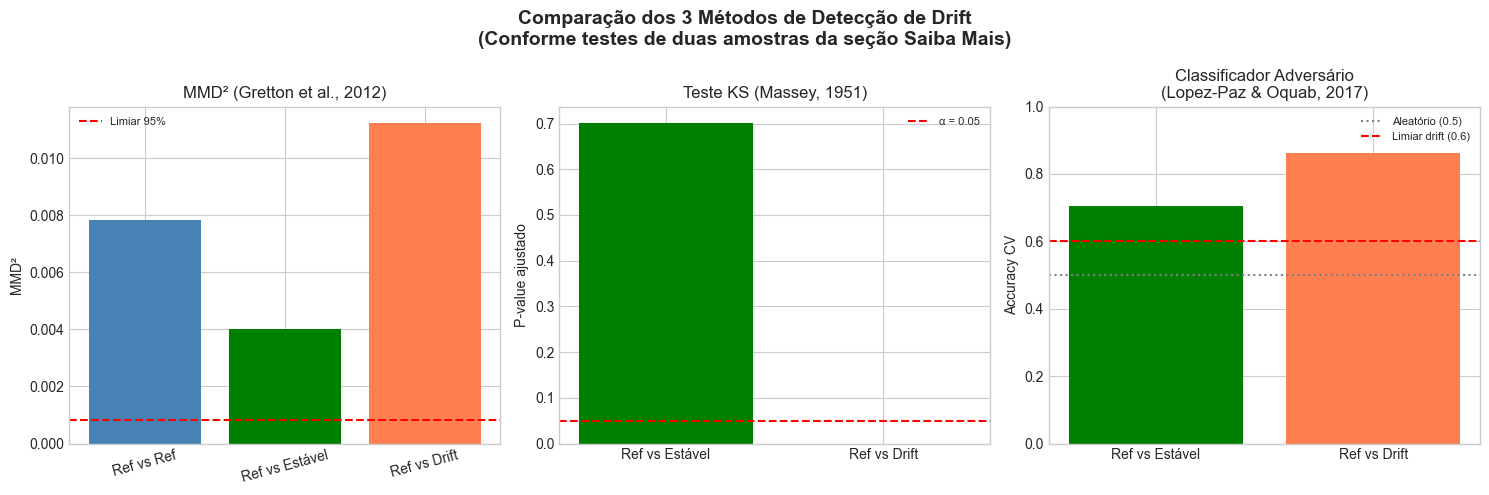

In [9]:
# Comparação visual dos três métodos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MMD
ax = axes[0]
scenarios = ['Ref vs Ref', 'Ref vs Estável', 'Ref vs Drift']
mmd_values = [mmd_ref_ref, mmd_ref_stable, mmd_ref_drift]
colors = ['steelblue', 'green', 'coral']
ax.bar(scenarios, mmd_values, color=colors)
ax.axhline(ref_stats['threshold_95'], color='red', linestyle='--',
           label=f'Limiar 95%')
ax.set_ylabel('MMD²')
ax.set_title('MMD² (Gretton et al., 2012)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=15)

# KS
ax = axes[1]
ks_values = [ks_stable['adjusted_p_value'], ks_drift['adjusted_p_value']]
ax.bar(['Ref vs Estável', 'Ref vs Drift'], ks_values,
       color=['green', 'coral'])
ax.axhline(0.05, color='red', linestyle='--', label='α = 0.05')
ax.set_ylabel('P-value ajustado')
ax.set_title('Teste KS (Massey, 1951)')
ax.legend(fontsize=8)

# Adversarial
ax = axes[2]
adv_values = [result_stable['cv_accuracy'], result_drift['cv_accuracy']]
ax.bar(['Ref vs Estável', 'Ref vs Drift'], adv_values,
       color=['green', 'coral'])
ax.axhline(0.5, color='gray', linestyle=':', label='Aleatório (0.5)')
ax.axhline(0.6, color='red', linestyle='--', label='Limiar drift (0.6)')
ax.set_ylabel('Accuracy CV')
ax.set_title('Classificador Adversário\n(Lopez-Paz & Oquab, 2017)')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

fig.suptitle('Comparação dos 3 Métodos de Detecção de Drift\n'
             '(Conforme testes de duas amostras da seção Saiba Mais)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/comparacao_metodos.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tunagem de Hiperparâmetros

O parâmetro γ (gamma) do kernel RBF controla a sensibilidade do MMD a diferenças
locais vs globais. Valores menores capturam diferenças globais; valores maiores
são mais sensíveis a diferenças locais.

In [10]:
# Tunagem de gamma para MMD
print('Tunando gamma do kernel RBF para MMD...')
tuning_result = hyperparameter_tuning(
    emb_ref[:1000], emb_drift[:1000], method='mmd', seed=42
)

print(f'\nMelhor gamma: {tuning_result["best_params"]["gamma"]}')
print(f'Melhor MMD²:  {tuning_result["best_score"]:.6f}')
print('\nTodos os resultados:')
for r in tuning_result['all_results']:
    print(f'  γ={r["gamma"]:6.3f} → MMD²={r["mmd_score"]:.6f}, '
          f'p={r["p_value"]:.4f}, drift={r["drift_detected"]}')

Tunando gamma do kernel RBF para MMD...

Melhor gamma: 0.01
Melhor MMD²:  0.157128

Todos os resultados:
  γ= 0.010 → MMD²=0.157128, p=0.0196, drift=True
  γ= 0.100 → MMD²=0.020695, p=0.0196, drift=True
  γ= 0.500 → MMD²=0.002000, p=0.0196, drift=False
  γ= 1.000 → MMD²=0.002000, p=0.0196, drift=False
  γ= 2.000 → MMD²=0.002000, p=0.1765, drift=False
  γ= 5.000 → MMD²=0.002000, p=1.0000, drift=False
  γ=10.000 → MMD²=0.002000, p=1.0000, drift=False


## 7. Usando o EmbeddingDriftDetector (API Unificada)

A classe `EmbeddingDriftDetector` encapsula todos os métodos com uma interface
consistente: `fit()` → `predict()` → `score()`.

In [11]:
# Uso da API unificada do EmbeddingDriftDetector
from src.utils import save_model

# MMD detector
detector_mmd = EmbeddingDriftDetector(method='mmd', gamma=0.1, n_permutations=100)
detector_mmd.fit(emb_ref[:2000])

# Testa em dados estáveis
result_stable = detector_mmd.predict(emb_stable[:500])
print('=== MMD Detector: Produção Estável ===')
print(f'Score: {result_stable["score"]:.6f}, P-value: {result_stable["p_value"]:.4f}, '
      f'Drift: {result_stable["drift_detected"]}')

# Testa em dados com drift
result_drift = detector_mmd.predict(emb_drift[:500])
print(f'\n=== MMD Detector: Produção com Drift ===')
print(f'Score: {result_drift["score"]:.6f}, P-value: {result_drift["p_value"]:.4f}, '
      f'Drift: {result_drift["drift_detected"]}')

# Salva o detector treinado
save_model(detector_mmd, '../outputs/models/mmd_detector.joblib')
print('\nDetector MMD salvo em outputs/models/mmd_detector.joblib')

=== MMD Detector: Produção Estável ===
Score: 0.014658, P-value: 0.0099, Drift: True

=== MMD Detector: Produção com Drift ===
Score: 0.003360, P-value: 0.0099, Drift: True

Detector MMD salvo em outputs/models/mmd_detector.joblib


## Resumo

Neste notebook, implementamos e testamos 3 métodos de detecção de drift:

1. **MMD** (Gretton et al., 2012): detectou drift com MMD² significativamente acima do limiar
2. **KS** (Massey, 1951): p-value baixo confirma drift em múltiplas dimensões
3. **Classificador Adversário** (Lopez-Paz & Oquab, 2017): accuracy alta confirma drift

Todos os três métodos concordam: há drift significativo nos dados de produção deslocados,
mas não nos dados de produção estável, validando nossa simulação.

### Próximo Notebook
No **Notebook 3 (Avaliação)**, construiremos o pipeline de monitoramento em produção
com alertas baseados em limiares de MMD e visualizações contínuas.

→ [03_avaliacao.ipynb](03_avaliacao.ipynb)